In [1]:
import pandas as pd
import numpy as np
from google.colab import drive

drive.mount('/content/drive')

train_df = pd.read_csv("/content/drive/MyDrive/dataset1/customer_churn_dataset-training-master.csv")
test_df = pd.read_csv("/content/drive/MyDrive/dataset1/customer_churn_dataset-testing-master.csv")
print(train_df.head())

Mounted at /content/drive
   CustomerID   Age  Gender  Tenure  Usage Frequency  Support Calls  \
0         2.0  30.0  Female    39.0             14.0            5.0   
1         3.0  65.0  Female    49.0              1.0           10.0   
2         4.0  55.0  Female    14.0              4.0            6.0   
3         5.0  58.0    Male    38.0             21.0            7.0   
4         6.0  23.0    Male    32.0             20.0            5.0   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0           18.0          Standard          Annual        932.0   
1            8.0             Basic         Monthly        557.0   
2           18.0             Basic       Quarterly        185.0   
3            7.0          Standard         Monthly        396.0   
4            8.0             Basic         Monthly        617.0   

   Last Interaction  Churn  
0              17.0    1.0  
1               6.0    1.0  
2               3.0    1.0  
3              29.0    1.0  

In [2]:

print(train_df.shape)



(440833, 12)


In [3]:
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB
None


In [4]:
print(train_df.describe())

          CustomerID            Age         Tenure  Usage Frequency  \
count  440832.000000  440832.000000  440832.000000    440832.000000   
mean   225398.667955      39.373153      31.256336        15.807494   
std    129531.918550      12.442369      17.255727         8.586242   
min         2.000000      18.000000       1.000000         1.000000   
25%    113621.750000      29.000000      16.000000         9.000000   
50%    226125.500000      39.000000      32.000000        16.000000   
75%    337739.250000      48.000000      46.000000        23.000000   
max    449999.000000      65.000000      60.000000        30.000000   

       Support Calls  Payment Delay    Total Spend  Last Interaction  \
count  440832.000000  440832.000000  440832.000000     440832.000000   
mean        3.604437      12.965722     631.616223         14.480868   
std         3.070218       8.258063     240.803001          8.596208   
min         0.000000       0.000000     100.000000          1.000000   


In [5]:
print(train_df.isnull().sum())
print(test_df.isnull().sum())

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


In [6]:
num_cols = train_df.select_dtypes(include=np.number).columns

for col in num_cols:
    train_df[col] = train_df[col].fillna(train_df[col].mean())
    test_df[col] = test_df[col].fillna(test_df[col].mean())

cat_cols = train_df.select_dtypes(include='object').columns

for col in cat_cols:
    train_df[col] = train_df[col].fillna(train_df[col].mode()[0])
    test_df[col] = test_df[col].fillna(test_df[col].mode()[0])

In [7]:
print(train_df.duplicated().sum())

0


In [8]:
train_df.drop_duplicates(inplace=True)
test_df.drop_duplicates(inplace=True)

print(train_df.shape)
print(test_df.shape)

(440833, 12)
(64374, 12)


In [9]:
from sklearn.preprocessing import LabelEncoder

cat_cols = train_df.select_dtypes(include='object').columns

for col in cat_cols:

    le = LabelEncoder()

    combined = pd.concat([
        train_df[col],
        test_df[col]
    ])

    le.fit(combined)

    train_df[col] = le.transform(train_df[col])
    test_df[col] = le.transform(test_df[col])

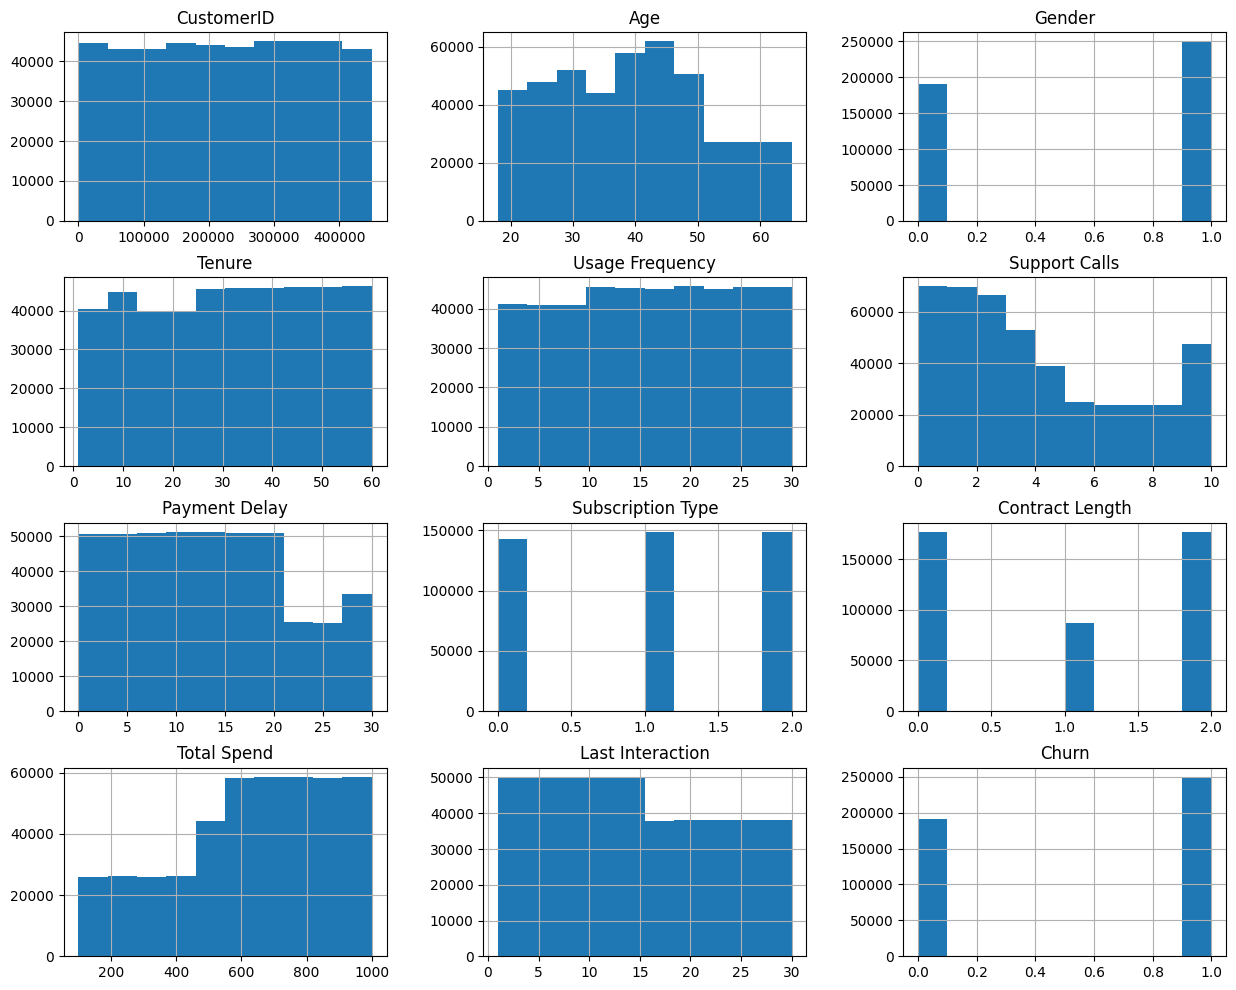

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

train_df.hist(figsize=(15,12))
plt.show()

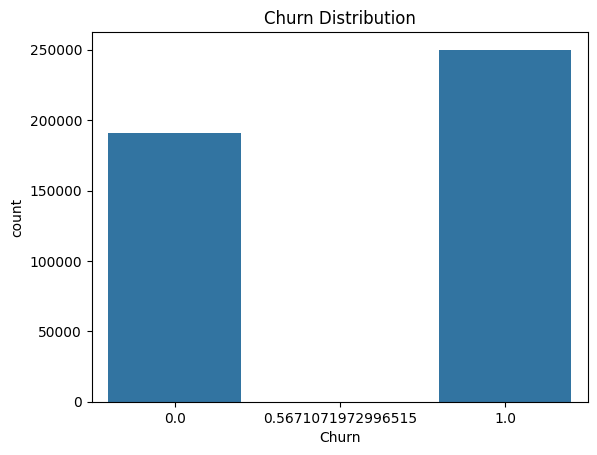

In [11]:
sns.countplot(x='Churn', data=train_df)
plt.title("Churn Distribution")
plt.show()

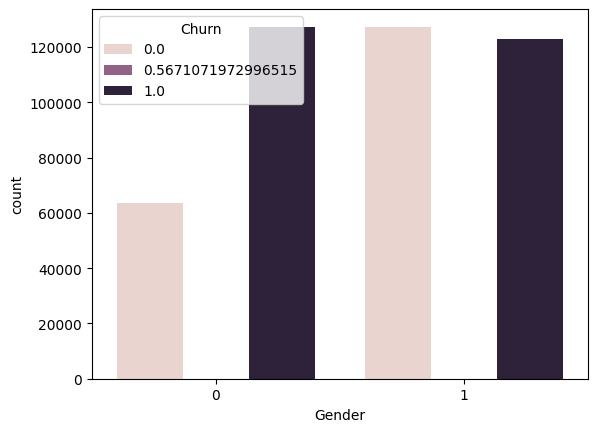

In [12]:
sns.countplot(x='Gender', hue='Churn', data=train_df)
plt.show()

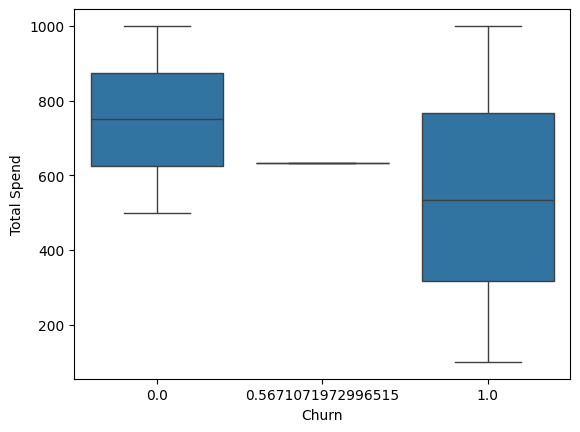

In [13]:
sns.boxplot(x='Churn', y='Total Spend', data=train_df)
plt.show()

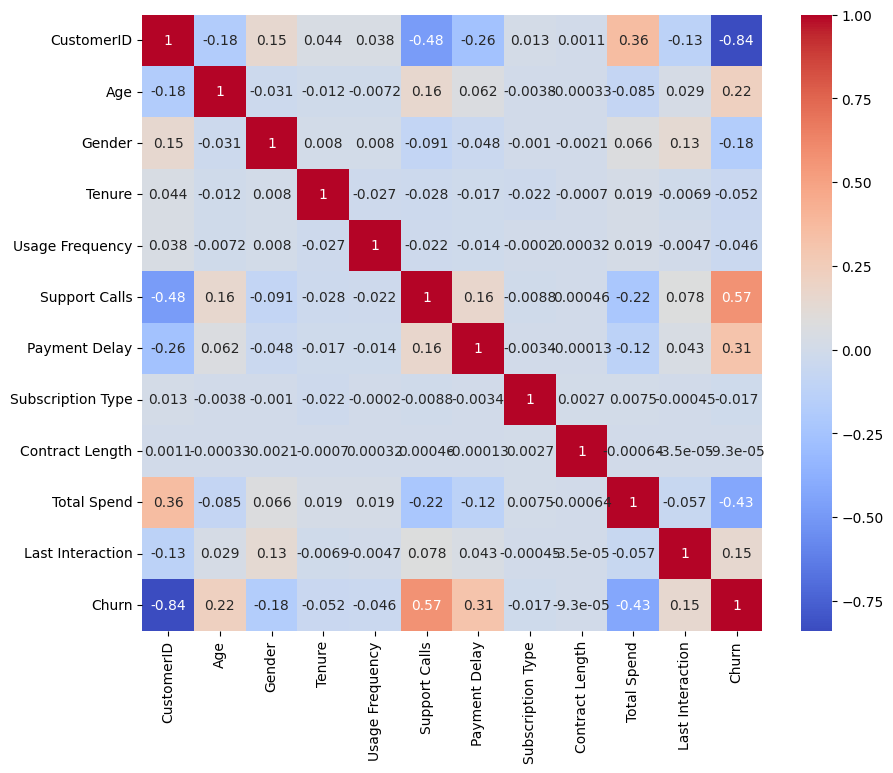

In [14]:
plt.figure(figsize=(10,8))

sns.heatmap(
    train_df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [15]:
train_df['Engagement Score'] = train_df['Usage Frequency'] * train_df['Tenure']
test_df['Engagement Score'] = test_df['Usage Frequency'] * test_df['Tenure']

train_df['Spend Per Month'] = train_df['Total Spend'] / (train_df['Tenure'] + 1)
test_df['Spend Per Month'] = test_df['Total Spend'] / (test_df['Tenure'] + 1)

train_df['Support Risk Score'] = train_df['Support Calls'] * train_df['Payment Delay']
test_df['Support Risk Score'] = test_df['Support Calls'] * test_df['Payment Delay']

In [16]:
train_df['Churn'] = pd.to_numeric(train_df['Churn'], errors='coerce')
train_df['Churn'] = train_df['Churn'].round().astype(int)

In [17]:
X = train_df.drop(['CustomerID','Churn'], axis=1)
y = train_df['Churn']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [20]:
models = {

    "Logistic Regression":
    LogisticRegression(max_iter=5000),

    "Decision Tree":
    DecisionTreeClassifier(random_state=42),

    "KNN":
    KNeighborsClassifier(n_neighbors=5),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    results.append([name, acc])

results_df = pd.DataFrame(
    results,
    columns=["Model","Accuracy"]
)

print(results_df)

                 Model  Accuracy
0  Logistic Regression  0.852212
1        Decision Tree  0.999376
2                  KNN  0.864065
3        Random Forest  0.999603


In [21]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [22]:
accuracy = accuracy_score(y_test, rf_pred)

print("Accuracy =", accuracy)

Accuracy = 0.9996030260755158


In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     38167
           1       1.00      1.00      1.00     50000

    accuracy                           1.00     88167
   macro avg       1.00      1.00      1.00     88167
weighted avg       1.00      1.00      1.00     88167



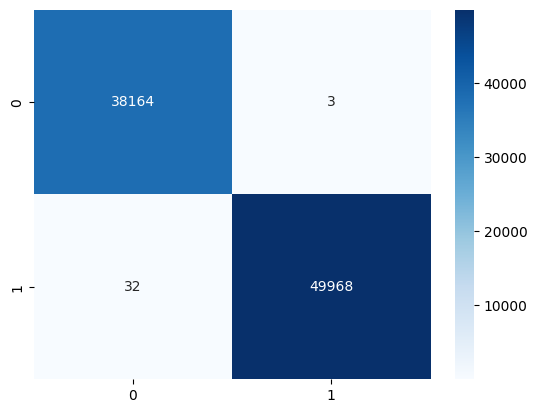

In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.show()

In [25]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)



               Feature  Importance
4        Support Calls    0.264123
8          Total Spend    0.186593
0                  Age    0.142563
5        Payment Delay    0.120331
12  Support Risk Score    0.081537
7      Contract Length    0.081307
9     Last Interaction    0.039225
11     Spend Per Month    0.034015
1               Gender    0.032711
2               Tenure    0.008224
10    Engagement Score    0.004456
3      Usage Frequency    0.003265
6    Subscription Type    0.001650


In [26]:
age = int(input("Enter Age: "))
gender = int(input("Enter Gender (0=Female,1=Male): "))
tenure = int(input("Enter Tenure: "))
usage = int(input("Enter Usage Frequency: "))
support = int(input("Enter Support Calls: "))
delay = int(input("Enter Payment Delay: "))
subscription = int(input("Enter Subscription Type: "))
contract = int(input("Enter Contract Length: "))
spend = float(input("Enter Total Spend: "))
interaction = int(input("Enter Last Interaction: "))

engagement = usage * tenure
spend_per_month = spend / (tenure + 1)
support_risk = support * delay
new_customer = pd.DataFrame({

    'Age':[age],
    'Gender':[gender],
    'Tenure':[tenure],
    'Usage Frequency':[usage],
    'Support Calls':[support],
    'Payment Delay':[delay],
    'Subscription Type':[subscription],
    'Contract Length':[contract],
    'Total Spend':[spend],
    'Last Interaction':[interaction],
    'Engagement Score':[engagement],
    'Spend Per Month':[spend_per_month],
    'Support Risk Score':[support_risk]

})

prediction = rf.predict(new_customer)
print("\nPrediction Result\n")

if prediction[0] == 1:

    print("YES - Customer Likely To Churn")

    print("\nRecommendations:")

    print("- Improve customer engagement")
    print("- Offer loyalty rewards")
    print("- Provide discounts")

    print("- Improve customer support")

else:

    print("NO - Customer Will Stay")

    print("\nRecommendation:")
    print("- Continue current customer engagement strategy")

Enter Age: 35
Enter Gender (0=Female,1=Male): 1
Enter Tenure: 12
Enter Usage Frequency: 17
Enter Support Calls: 1
Enter Payment Delay: 2
Enter Subscription Type: 2
Enter Contract Length: 1
Enter Total Spend: 1500
Enter Last Interaction: 2

Prediction Result

YES - Customer Likely To Churn

Recommendations:
- Improve customer engagement
- Offer loyalty rewards
- Provide discounts
- Improve customer support
